In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (108, 115)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find Signed EPI variants
signed_epi_variants = find_index_variants(df.columns, 'epi_signed')
ASSET_COLS = ['r_btc', 'r_gold', 'r_spx']
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nSigned EPI variants found: {len(signed_epi_variants)}")
for i, var in enumerate(signed_epi_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


Signed EPI variants found: 4
  1. epi_signed
  2. epi_signed_engweighted
  3. epi_signed_topicweighted
  4. epi_signed_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx']


## Descriptive Statistics


Descriptive Statistics

Signed EPI Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
epi_signed,108.0,-0.022008,0.059465,-0.226484,-0.036069,-0.023889,-0.009136,0.249999,1.270630,9.096201,0.0,1.851852
epi_signed_engweighted,108.0,-0.021472,0.058531,-0.226484,-0.036219,-0.023241,-0.009751,0.250000,1.237163,9.406519,0.0,1.851852
epi_signed_engweighted_topicweighted,108.0,-0.005606,0.015696,-0.069945,-0.011473,-0.002053,0.000000,0.061480,-0.048688,4.977966,0.0,10.185185
epi_signed_topicweighted,108.0,-0.019900,0.029034,-0.072610,-0.035672,-0.022615,-0.006308,0.121523,1.933147,7.534333,0.0,8.333333



Correlation between variants:


,epi_signed,epi_signed_engweighted,epi_signed_topicweighted,epi_signed_engweighted_topicweighted
epi_signed,1.000000,0.994720,0.261736,0.348034
epi_signed_engweighted,0.994720,1.000000,0.246435,0.357392
epi_signed_topicweighted,0.261736,0.246435,1.000000,0.280537
epi_signed_engweighted_topicweighted,0.348034,0.357392,0.280537,1.000000


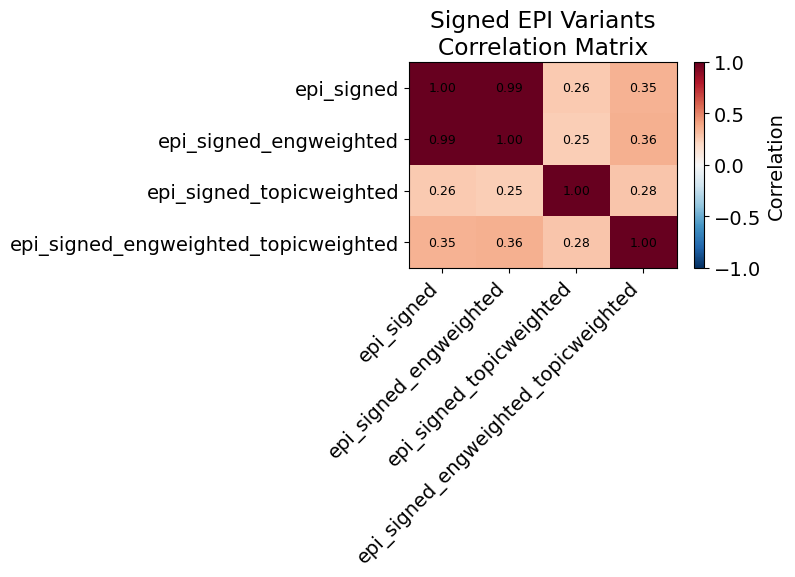

In [5]:
print("\n" + "="*70)
print("Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, signed_epi_variants, 'Signed EPI Variants')

## Time Series Visualization


Time Series Visualization


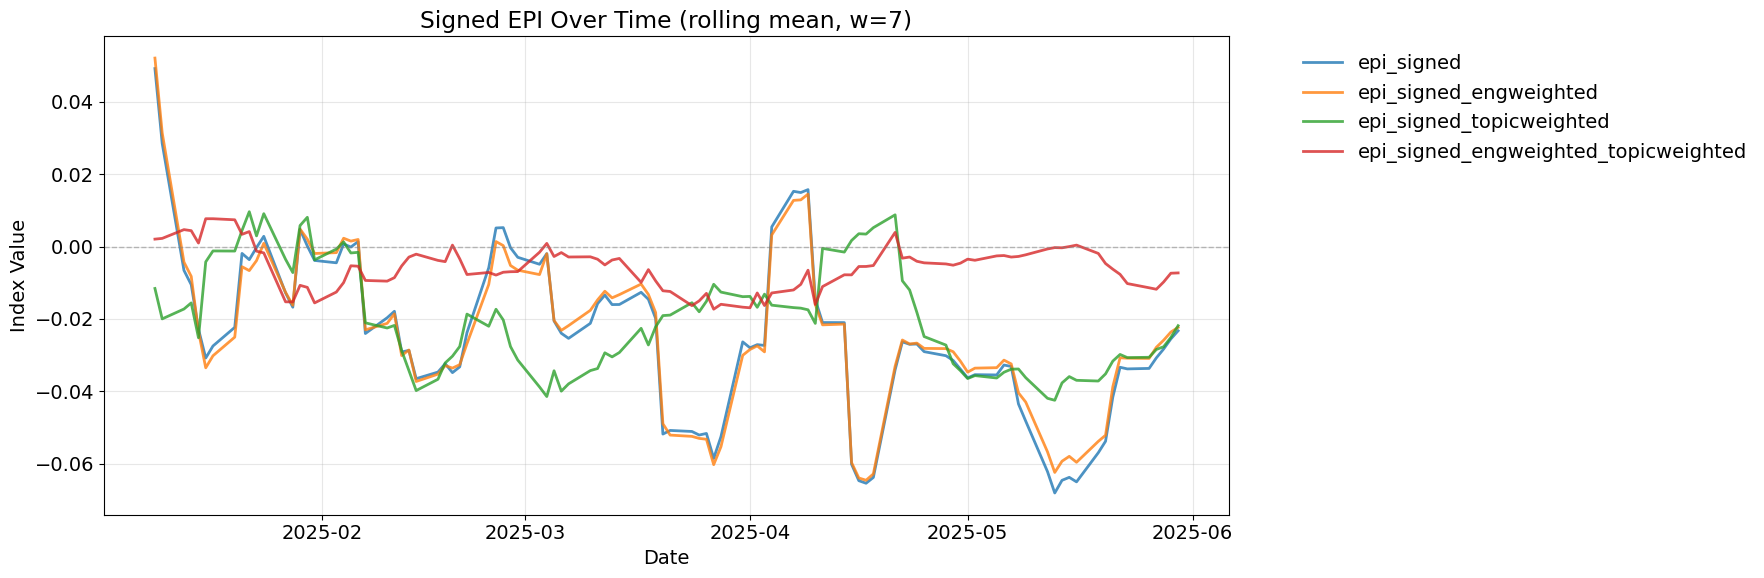

In [6]:
print("\n" + "="*70)
print("Time Series Visualization")
print("="*70)
compare_index_variants_timeseries(df, signed_epi_variants, 'Signed EPI Over Time', rolling_window=7)

## Rolling Correlations with Assets


Rolling Correlations with Assets


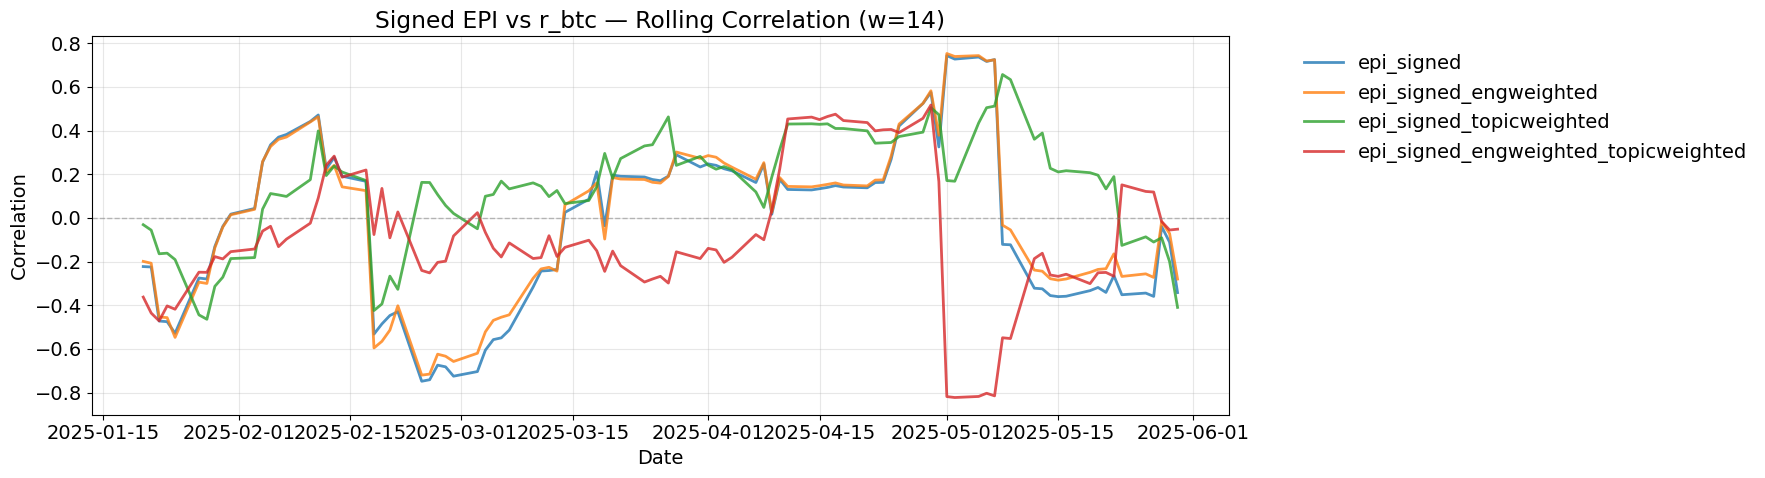

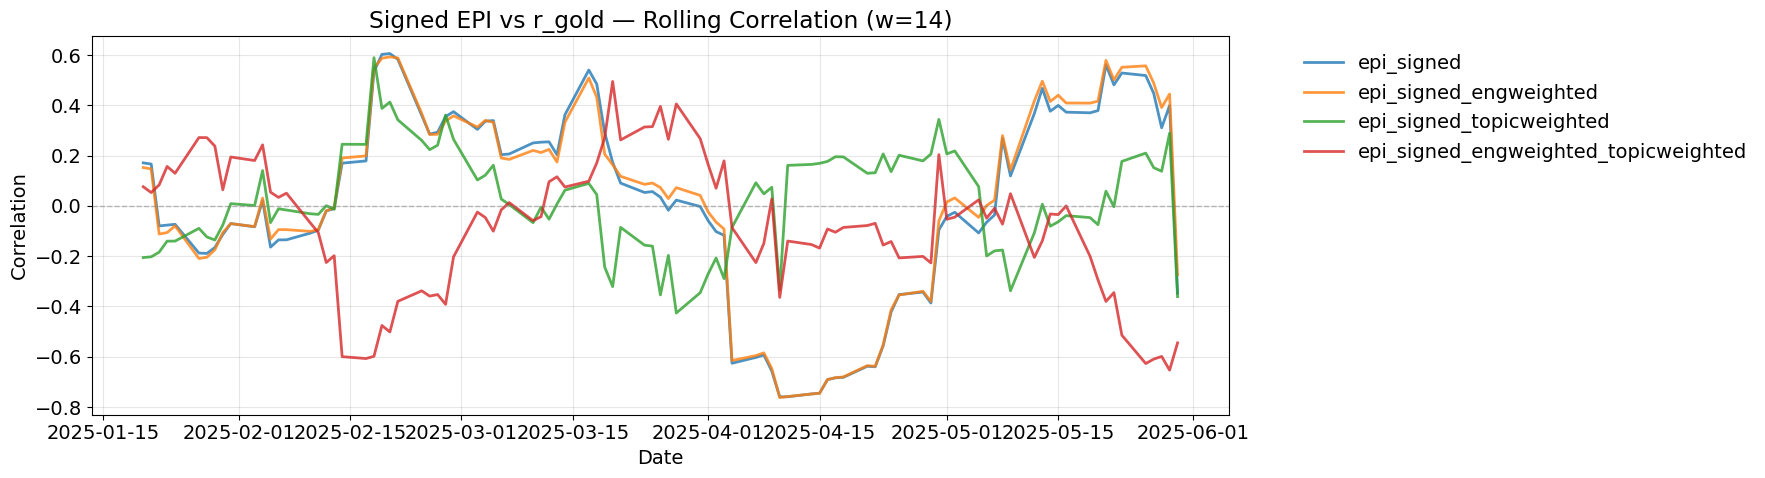

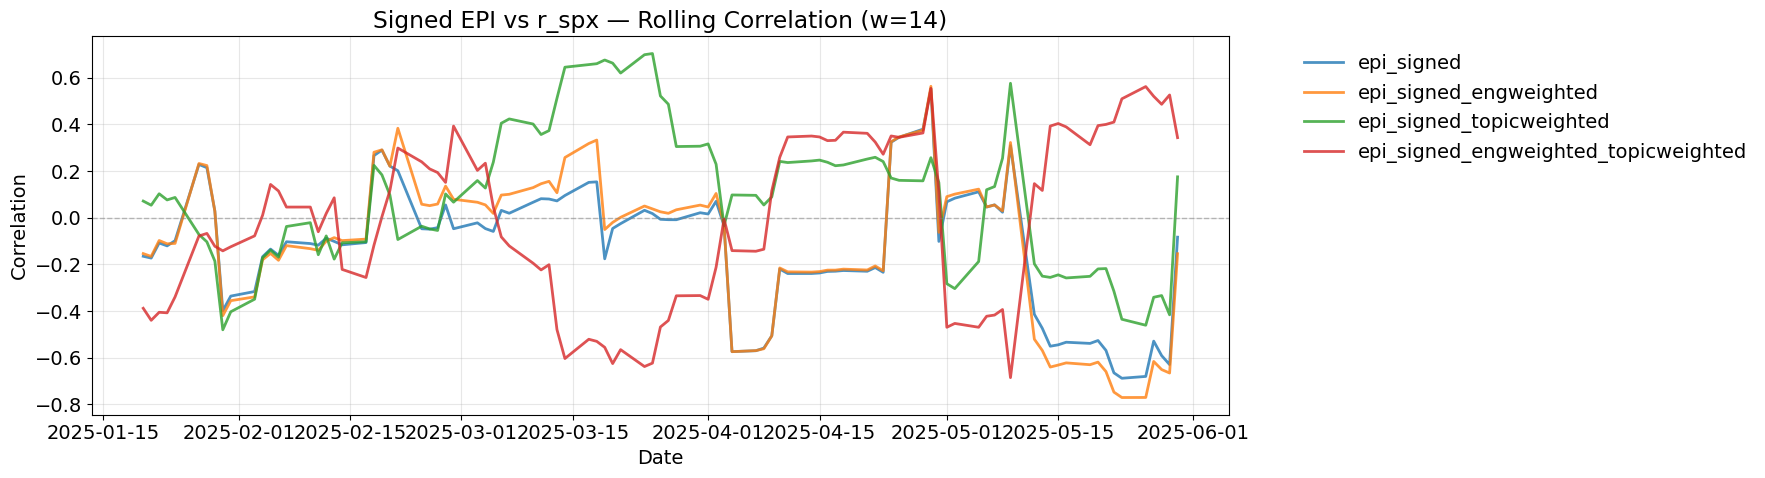

In [7]:
print("\n" + "="*70)
print("Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, signed_epi_variants, ASSET_COLS, 'Signed EPI', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if Signed EPI variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


Granger Causality Tests

GRANGER CAUSALITY TESTS: EPI Variants
Running 12 Granger causality tests...
  Index → Asset causality
  Max lag: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  Significant relationships (corrected α=0.05): 0 of 12
  Uncorrected significant (α=0.05): 0

P-values (at optimal lag):


asset,r_btc,r_gold,r_spx
index,,,
epi_signed,0.203084,0.416366,0.866747
epi_signed_engweighted,0.164126,0.368290,0.797823
epi_signed_engweighted_topicweighted,0.074824,0.547646,0.143050
epi_signed_topicweighted,0.346726,0.326027,0.807384



Corrected p-values (fdr_bh):


asset,r_btc,r_gold,r_spx
index,,,
epi_signed,0.609251,0.624549,0.866747
epi_signed_engweighted,0.609251,0.624549,0.866747
epi_signed_engweighted_topicweighted,0.609251,0.730195,0.609251
epi_signed_topicweighted,0.624549,0.624549,0.866747



Significant relationships (α=0.05, corrected):


asset,r_btc,r_gold,r_spx
index,,,
epi_signed,0,0,0
epi_signed_engweighted,0,0,0
epi_signed_engweighted_topicweighted,0,0,0
epi_signed_topicweighted,0,0,0


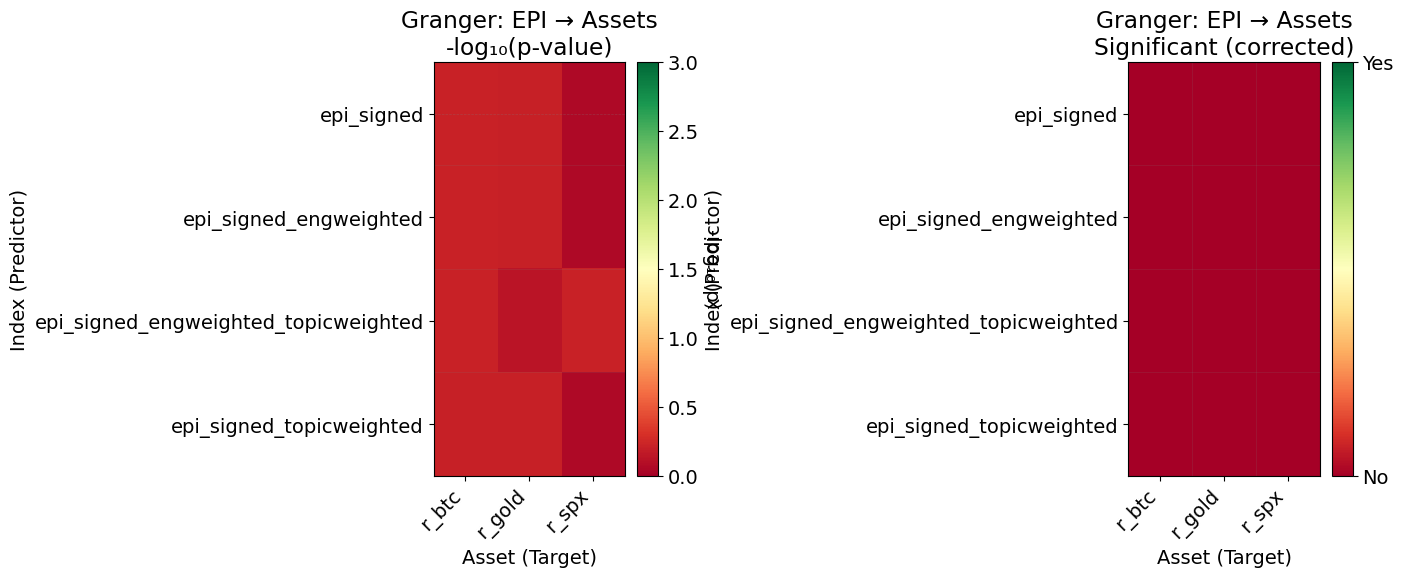

In [8]:
print("\n" + "="*70)
print("Granger Causality Tests")
print("="*70)

pval_mat, pval_corrected, sig_mat = granger_comparison_variants(
    df, signed_epi_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("Performance Summary")
print("="*70)
performance = summarize_variant_performance(pval_mat, sig_mat, signed_epi_variants)


Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant,mean_pvalue,min_pvalue
0,epi_signed,0,0.495399,0.203084
1,epi_signed_engweighted,0,0.443413,0.164126
2,epi_signed_topicweighted,0,0.493379,0.326027
3,epi_signed_engweighted_topicweighted,0,0.255173,0.074824


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in signed_epi_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)


,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,epi_signed,-9.080511,4.068232e-15,✓,0.614826,0.021289,✗
1,epi_signed_engweighted,-9.066912,4.407398e-15,✓,0.571565,0.025548,✗
2,epi_signed_topicweighted,-6.055912,1.245342e-07,✓,0.423621,0.066974,✓
3,epi_signed_engweighted_topicweighted,-12.010137,3.195090e-22,✓,0.207609,0.100000,✓



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


Bidirectional Granger Tests

Best variant: epi_signed


epi_signed ↔ r_btc:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_btc,1,0.203084,0.008795,True,False
1,r_btc → epi_signed,2,0.757850,0.008958,True,False



epi_signed ↔ r_gold:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_gold,1,0.416366,0.416366,False,False
1,r_gold → epi_signed,2,0.730721,0.458085,False,False



epi_signed ↔ r_spx:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi_signed → r_spx,1,0.866747,0.165032,False,False
1,r_spx → epi_signed,2,0.000354,0.000354,True,True


## Event Window Analysis

How do Signed EPI variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, signed_epi_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "signed_epi_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


Event Window Analysis


,event,phase,n,epi_signed_mean,epi_signed_std,epi_signed_engweighted_mean,epi_signed_engweighted_std,epi_signed_topicweighted_mean,epi_signed_topicweighted_std,epi_signed_engweighted_topicweighted_mean,epi_signed_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.012047,NaN,-0.008032,NaN,-0.014721,NaN,-0.025248,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.020315,NaN,0.021248,NaN,0.011378,NaN,0.006401,NaN
8,Tariffs Postponed,Δ during-pre,NaN,0.009008,NaN,0.007898,NaN,0.003258,NaN,-0.005832,NaN
9,Tariffs Postponed,Δ post-during,NaN,0.002630,NaN,0.004053,NaN,0.012013,NaN,0.001058,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,0.004383,NaN,0.001413,NaN,0.006464,NaN,0.003241,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,-0.053957,NaN,-0.051241,NaN,0.011951,NaN,-0.015837,NaN
18,Global Tariffs,Δ during-pre,NaN,0.091857,NaN,0.092357,NaN,-0.005095,NaN,0.009980,NaN
19,Global Tariffs,Δ post-during,NaN,-0.131769,NaN,-0.129428,NaN,0.022577,NaN,-0.002408,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,-0.138853,NaN,-0.135754,NaN,0.037077,NaN,-0.003882,NaN
24,US-China Tariff Threats,Δ post-during,NaN,0.074815,NaN,0.073750,NaN,-0.026813,NaN,0.011403,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of Signed EPI variants

In [14]:
print("\n" + "="*70)
print("SIGNED EPI VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(signed_epi_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in signed_epi_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:40s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:40s}: {int(row['n_significant'])} significant")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships: {int(performance.iloc[0]['n_significant'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value: {performance.iloc[0]['mean_pvalue']:.4f}")

print("\n5. KEY INSIGHTS:")
if len(signed_epi_variants) >= 2:
    corr_base_eng = df[[signed_epi_variants[0], signed_epi_variants[1]]].corr().iloc[0, 1]
    print(f"   - Base and engagement-weighted correlation: r={corr_base_eng:.3f}")
print(f"   - Directional sentiment captures positive-negative emotion asymmetry")
print(f"   - Potentially useful for predicting directional price movements")

print("\n" + "="*70)
print("✓ SIGNED EPI ANALYSIS COMPLETE")
print("="*70)


SIGNED EPI VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. epi_signed
   2. epi_signed_engweighted
   3. epi_signed_topicweighted
   4. epi_signed_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   epi_signed                              : 0.0882
   epi_signed_engweighted                  : 0.0778
   epi_signed_topicweighted                : 0.1067
   epi_signed_engweighted_topicweighted    : 0.0595

3. GRANGER CAUSALITY (significant relationships after FDR):
   epi_signed                              : 0 significant
   epi_signed_engweighted                  : 0 significant
   epi_signed_topicweighted                : 0 significant
   epi_signed_engweighted_topicweighted    : 0 significant

4. BEST PERFORMING VARIANT:
   epi_signed
   - Significant Granger relationships: 0/3
   - Mean p-value: 0.4954

5. KEY INSIGHTS:
   - Base and engagement-weighted correlation: r=0.995
   - Directional sentiment captures positive-negative emotion asymmetry
   - Poten